<a href="https://colab.research.google.com/github/LaithAlzubaidi1/LAITH-HATEM-DS/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("DS230 Project")


DS230 Project


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

import pandas as pd

df = pd.read_csv(
    'OnlineNewsPopularity.csv',
    sep=',',
    engine='python',
    on_bad_lines='skip'
)

In [ ]:
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,0.999999992308,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593.0
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,0.999999993289,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711.0
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,0.999999991597,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500.0
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,0.999999996904,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200.0
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,0.999999998565,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505.0


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58747 entries, 0 to 58746
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   url                             58747 non-null  object 
 1    timedelta                      58747 non-null  float64
 2    n_tokens_title                 58747 non-null  float64
 3    n_tokens_content               58747 non-null  float64
 4    n_unique_tokens                58747 non-null  float64
 5    n_non_stop_words               58747 non-null  object 
 6    n_non_stop_unique_tokens       58747 non-null  float64
 7    num_hrefs                      58747 non-null  float64
 8    num_self_hrefs                 58747 non-null  float64
 9    num_imgs                       58747 non-null  float64
 10   num_videos                     58746 non-null  float64
 11   average_token_length           58746 non-null  float64
 12   num_keywords                   

In [ ]:
df.isnull().sum()
df.describe()

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
count,58747.000000,58747.000000,58747.000000,58747.000000,58747.000000,58747.000000,58747.000000,58747.000000,58746.000000,58746.000000,...,58738.000000,58738.000000,58737.000000,58737.000000,58737.000000,58737.000000,58737.000000,58737.000000,58737.000000,58737.000000
mean,291.727015,12.028630,556.386936,2.481503,5.790053,10.848967,3.333555,4.721702,1.377643,4.679534,...,0.094251,0.818133,-0.259366,-0.527544,-0.105408,0.283457,0.067439,0.341507,0.155851,3333.955548
std,204.832371,355.612083,594.655972,373.320597,1237.032800,17.698374,35.661088,24.842811,30.787597,31.842175,...,0.070836,16.915879,0.128019,0.293818,0.093530,0.324564,0.265877,0.188670,0.225719,10803.343061
min,0.500000,-0.100000,-0.100000,-0.100000,-0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,1.000000
25%,122.000000,9.000000,251.000000,0.466754,0.622203,4.000000,1.000000,1.000000,0.000000,4.476435,...,0.050000,0.600000,-0.328942,-0.750000,-0.125000,0.000000,0.000000,0.166667,0.000000,952.000000
50%,244.000000,10.000000,419.000000,0.534413,0.686275,7.000000,2.000000,1.000000,0.000000,4.667683,...,0.100000,0.800000,-0.254630,-0.500000,-0.100000,0.150000,0.000000,0.500000,0.000000,1400.000000
75%,448.000000,12.000000,730.000000,0.602273,0.750000,14.000000,4.000000,4.000000,1.000000,4.859729,...,0.100000,1.000000,-0.187500,-0.300000,-0.050000,0.500000,0.136364,0.500000,0.250000,2700.000000
max,3732.439408,86200.000000,86200.000000,86200.000000,299828.571429,3286.750779,8601.358182,5358.310344,7400.000000,7400.000000,...,1.000000,4100.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.500000,1.000000,843300.000000


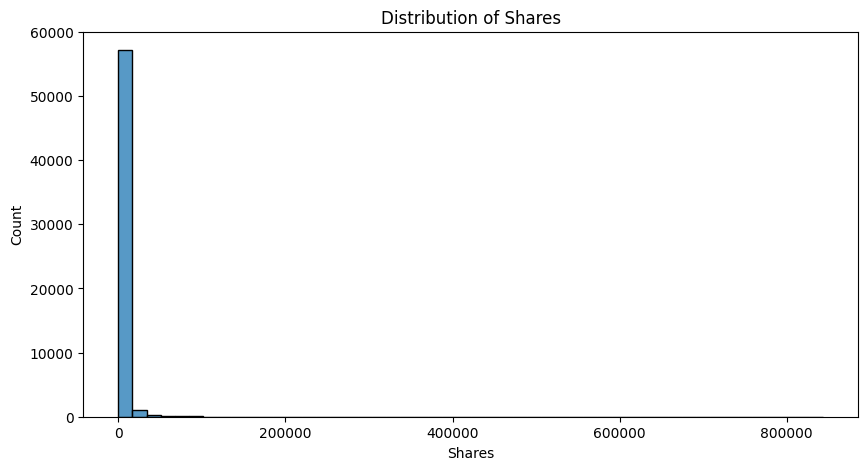

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df[' shares'], bins=50)

plt.title('Distribution of Shares')
plt.xlabel('Shares')
plt.ylabel('Count')

plt.show()

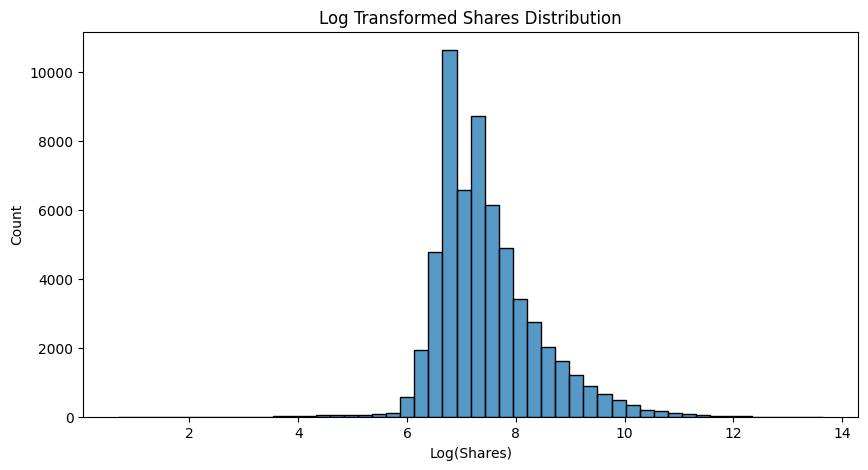

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(np.log1p(df[' shares']), bins=50)

plt.title('Log Transformed Shares Distribution')
plt.xlabel('Log(Shares)')
plt.ylabel('Count')

plt.show()


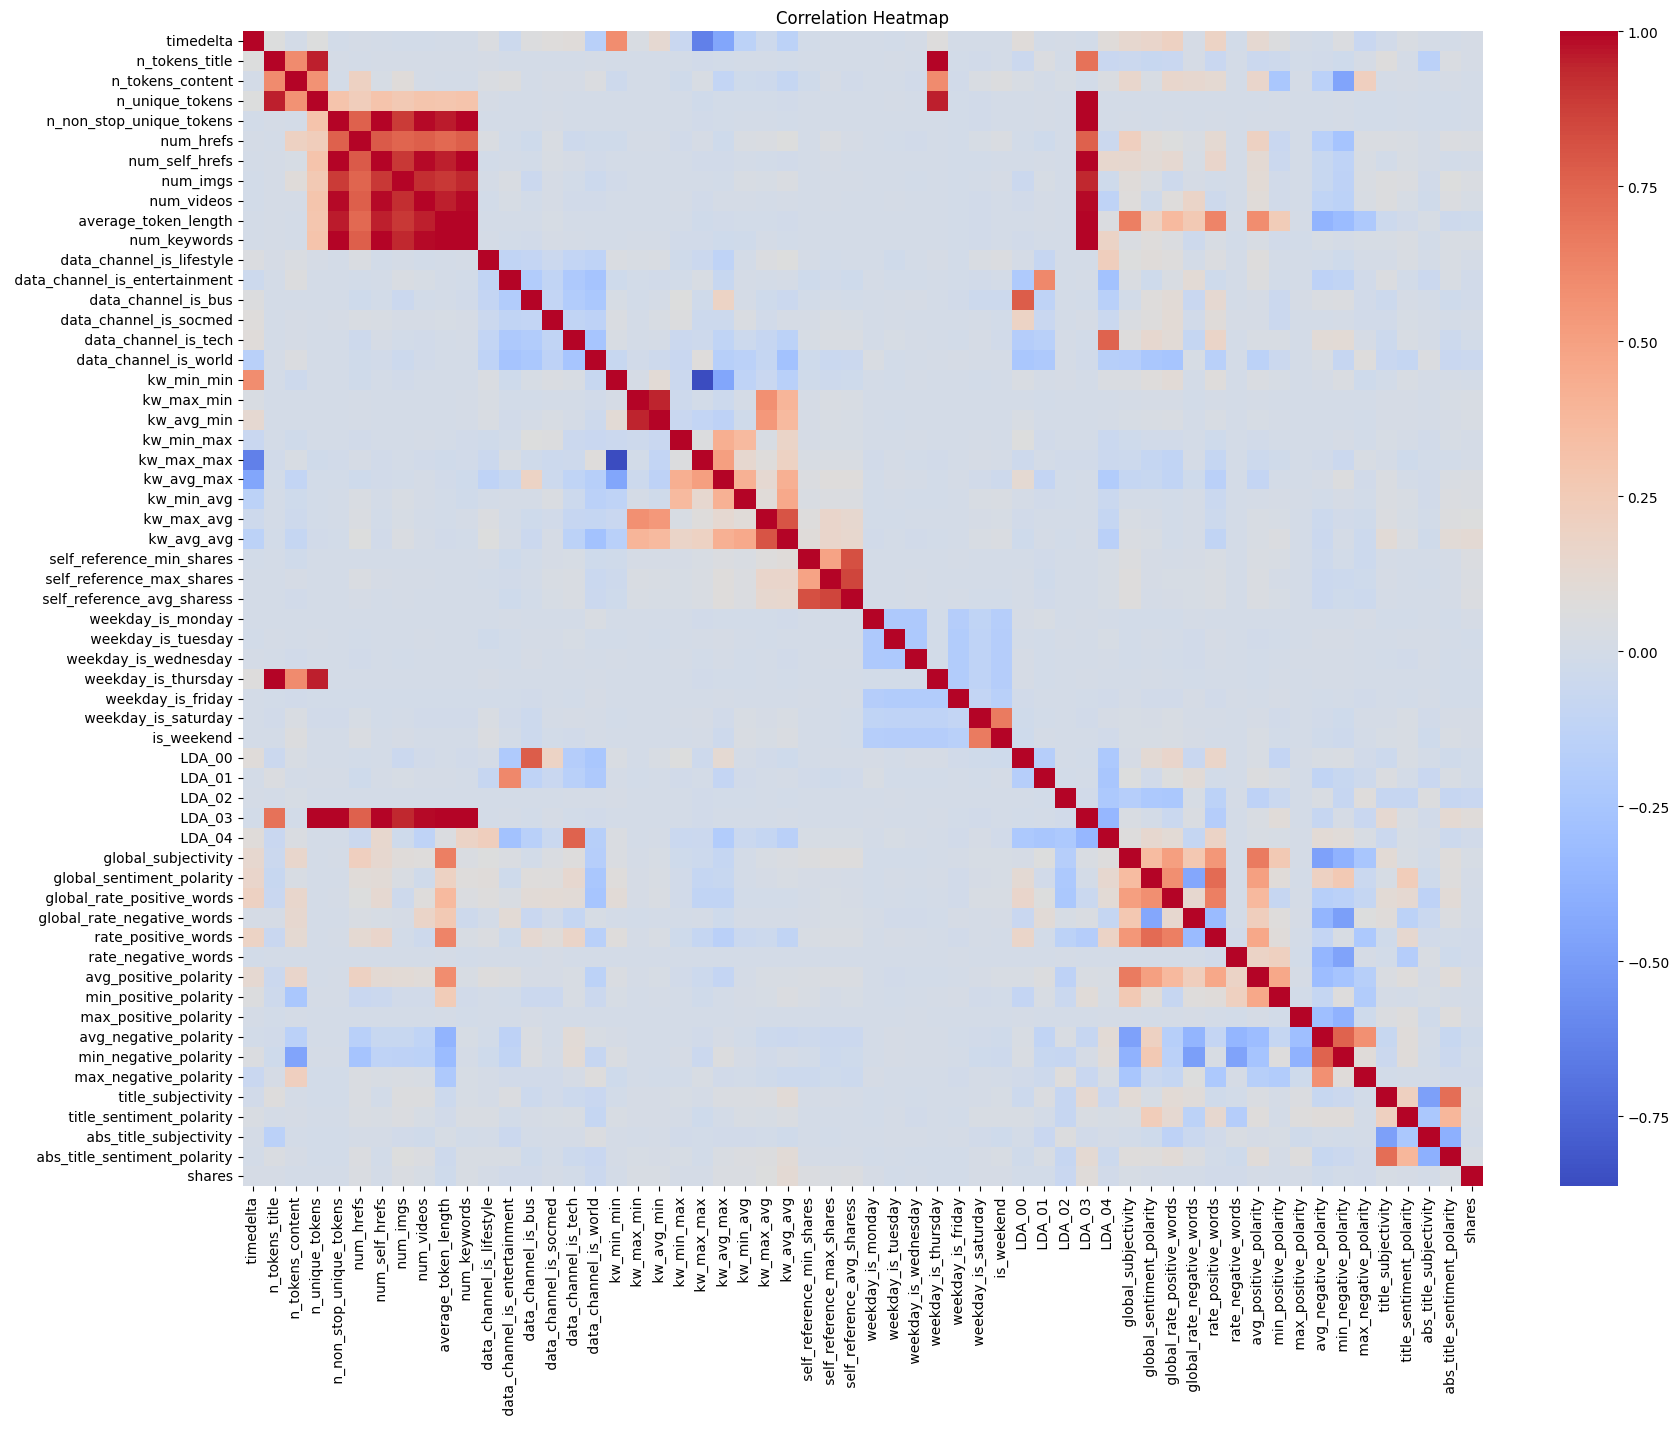

In [ ]:
plt.figure(figsize=(20,15))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(correlation_matrix, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()


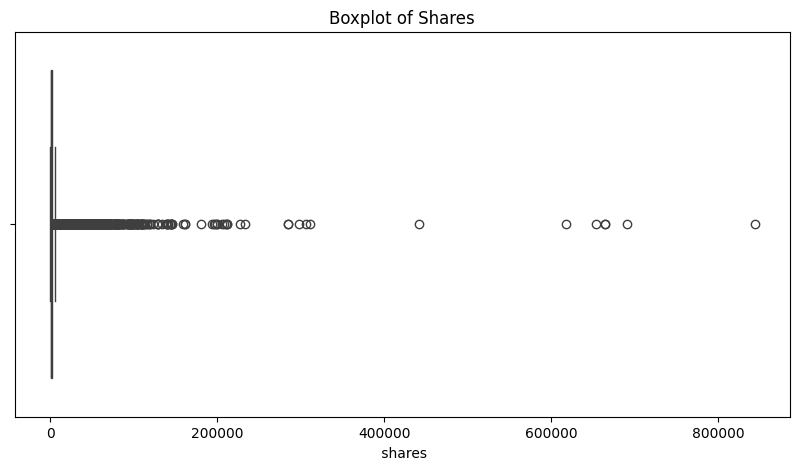

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df[' shares'])

plt.title('Boxplot of Shares')

plt.show()


In [ ]:
df.isnull().sum().sort_values(ascending=False).head(10)

,0
title_sentiment_polarity,10
title_subjectivity,10
max_negative_polarity,10
min_negative_polarity,10
avg_negative_polarity,10
shares,10
abs_title_sentiment_polarity,10
abs_title_subjectivity,10
avg_positive_polarity,9
min_positive_polarity,9


In [ ]:
df = df.dropna()
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df['log_shares'] = np.log1p(df[' shares'])
df[[' shares', 'log_shares']].head()

,shares,log_shares
0,593.0,6.386879
1,711.0,6.568078
2,1500.0,7.313887
3,1200.0,7.090910
4,505.0,6.226537


In [ ]:
median_shares = df[' shares'].median()

df['popular'] = (df[' shares'] > median_shares).astype(int)

df['popular'].value_counts()

,count
popular,
0,29961
1,28776


In [ ]:
X = df.drop([' shares', 'log_shares', 'popular', 'url'], axis=1)

y = df['popular']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6636023152877085


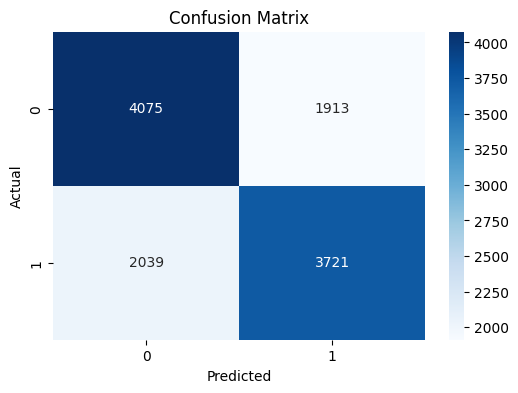

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

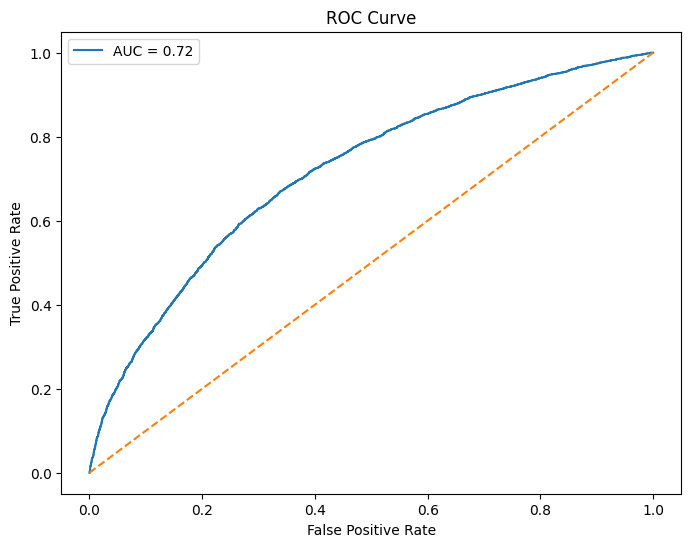

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)

In [ ]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8369084099421178


In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84      5988
           1       0.83      0.84      0.83      5760

    accuracy                           0.84     11748
   macro avg       0.84      0.84      0.84     11748
weighted avg       0.84      0.84      0.84     11748



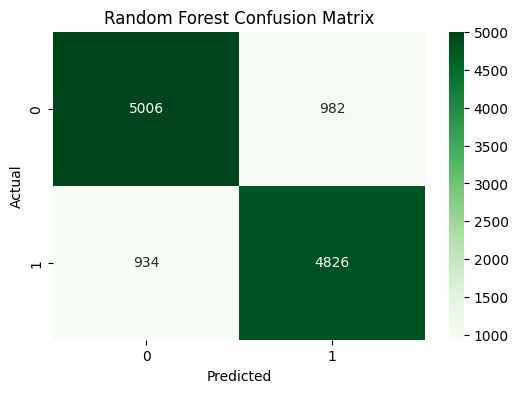

In [ ]:
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens')

plt.title('Random Forest Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

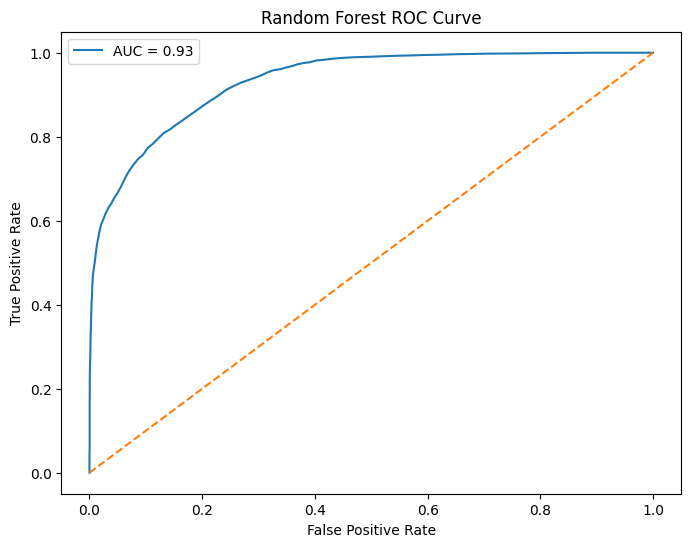

In [ ]:
rf_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.title('Random Forest ROC Curve')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend()

plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
26,kw_avg_avg,0.042157
25,kw_max_avg,0.040044
40,LDA_02,0.032124
27,self_reference_min_shares,0.031974
0,timedelta,0.030155
39,LDA_01,0.029368
29,self_reference_avg_sharess,0.029333
38,LDA_00,0.028618
42,LDA_04,0.028511
23,kw_avg_max,0.027944


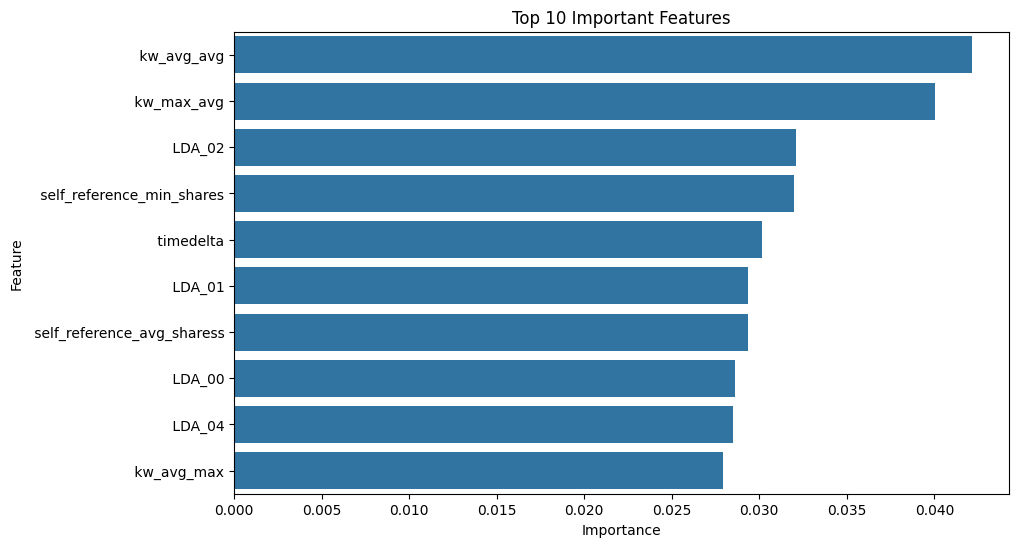

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title('Top 10 Important Features')

plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy)



KNN Accuracy: 0.6710929519918284


In [ ]:
!pip install xgboost

In [ ]:
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb_model.predict(X_test)

In [ ]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.7159516513449098


In [ ]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.72      0.73      0.72      5988
           1       0.72      0.70      0.71      5760

    accuracy                           0.72     11748
   macro avg       0.72      0.72      0.72     11748
weighted avg       0.72      0.72      0.72     11748



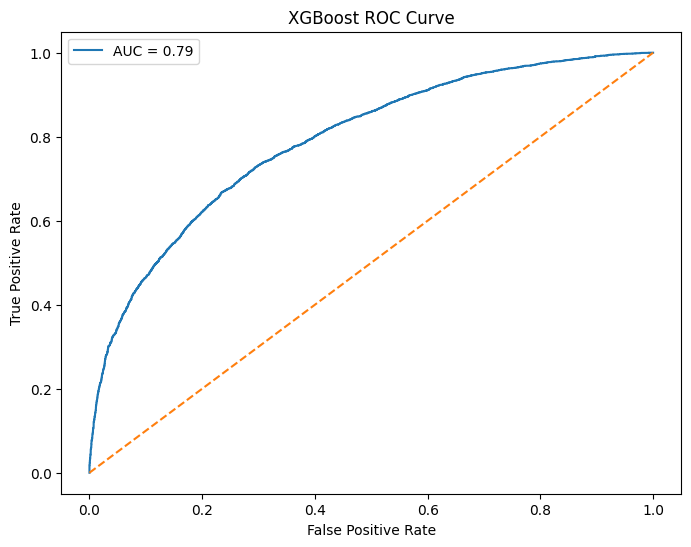

In [ ]:
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, xgb_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.title('XGBoost ROC Curve')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend()

plt.show()

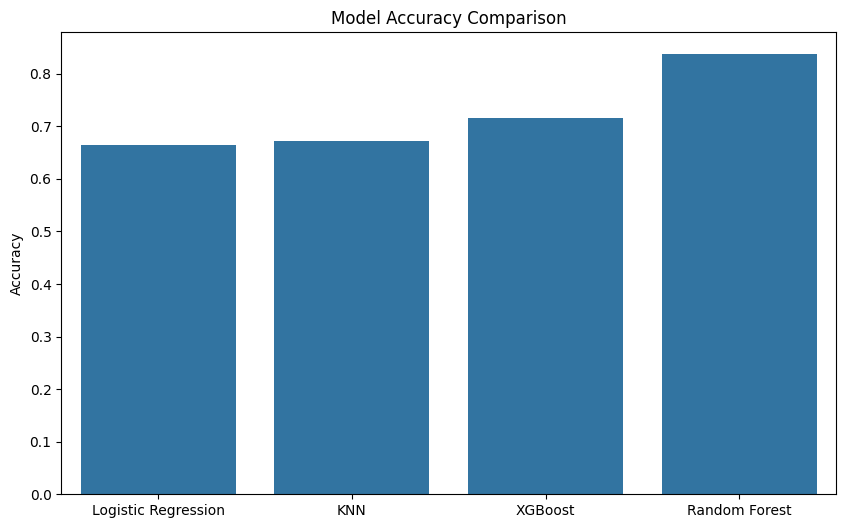

In [ ]:
models = ['Logistic Regression', 'KNN', 'XGBoost', 'Random Forest']

accuracies = [
    accuracy,
    knn_accuracy,
    xgb_accuracy,
    rf_accuracy
]

plt.figure(figsize=(10,6))

sns.barplot(
    x=models,
    y=accuracies
)

plt.title('Model Accuracy Comparison')

plt.ylabel('Accuracy')

plt.show()